OpenCV Version: 4.13.0
Завантаження зображень...
Зображення успішно завантажені!

Піксель на (50, 100) -> Червоний (R): 151, Зелений (G): 151, Синій (B): 151

--- Відображення загальної сітки зображень ---


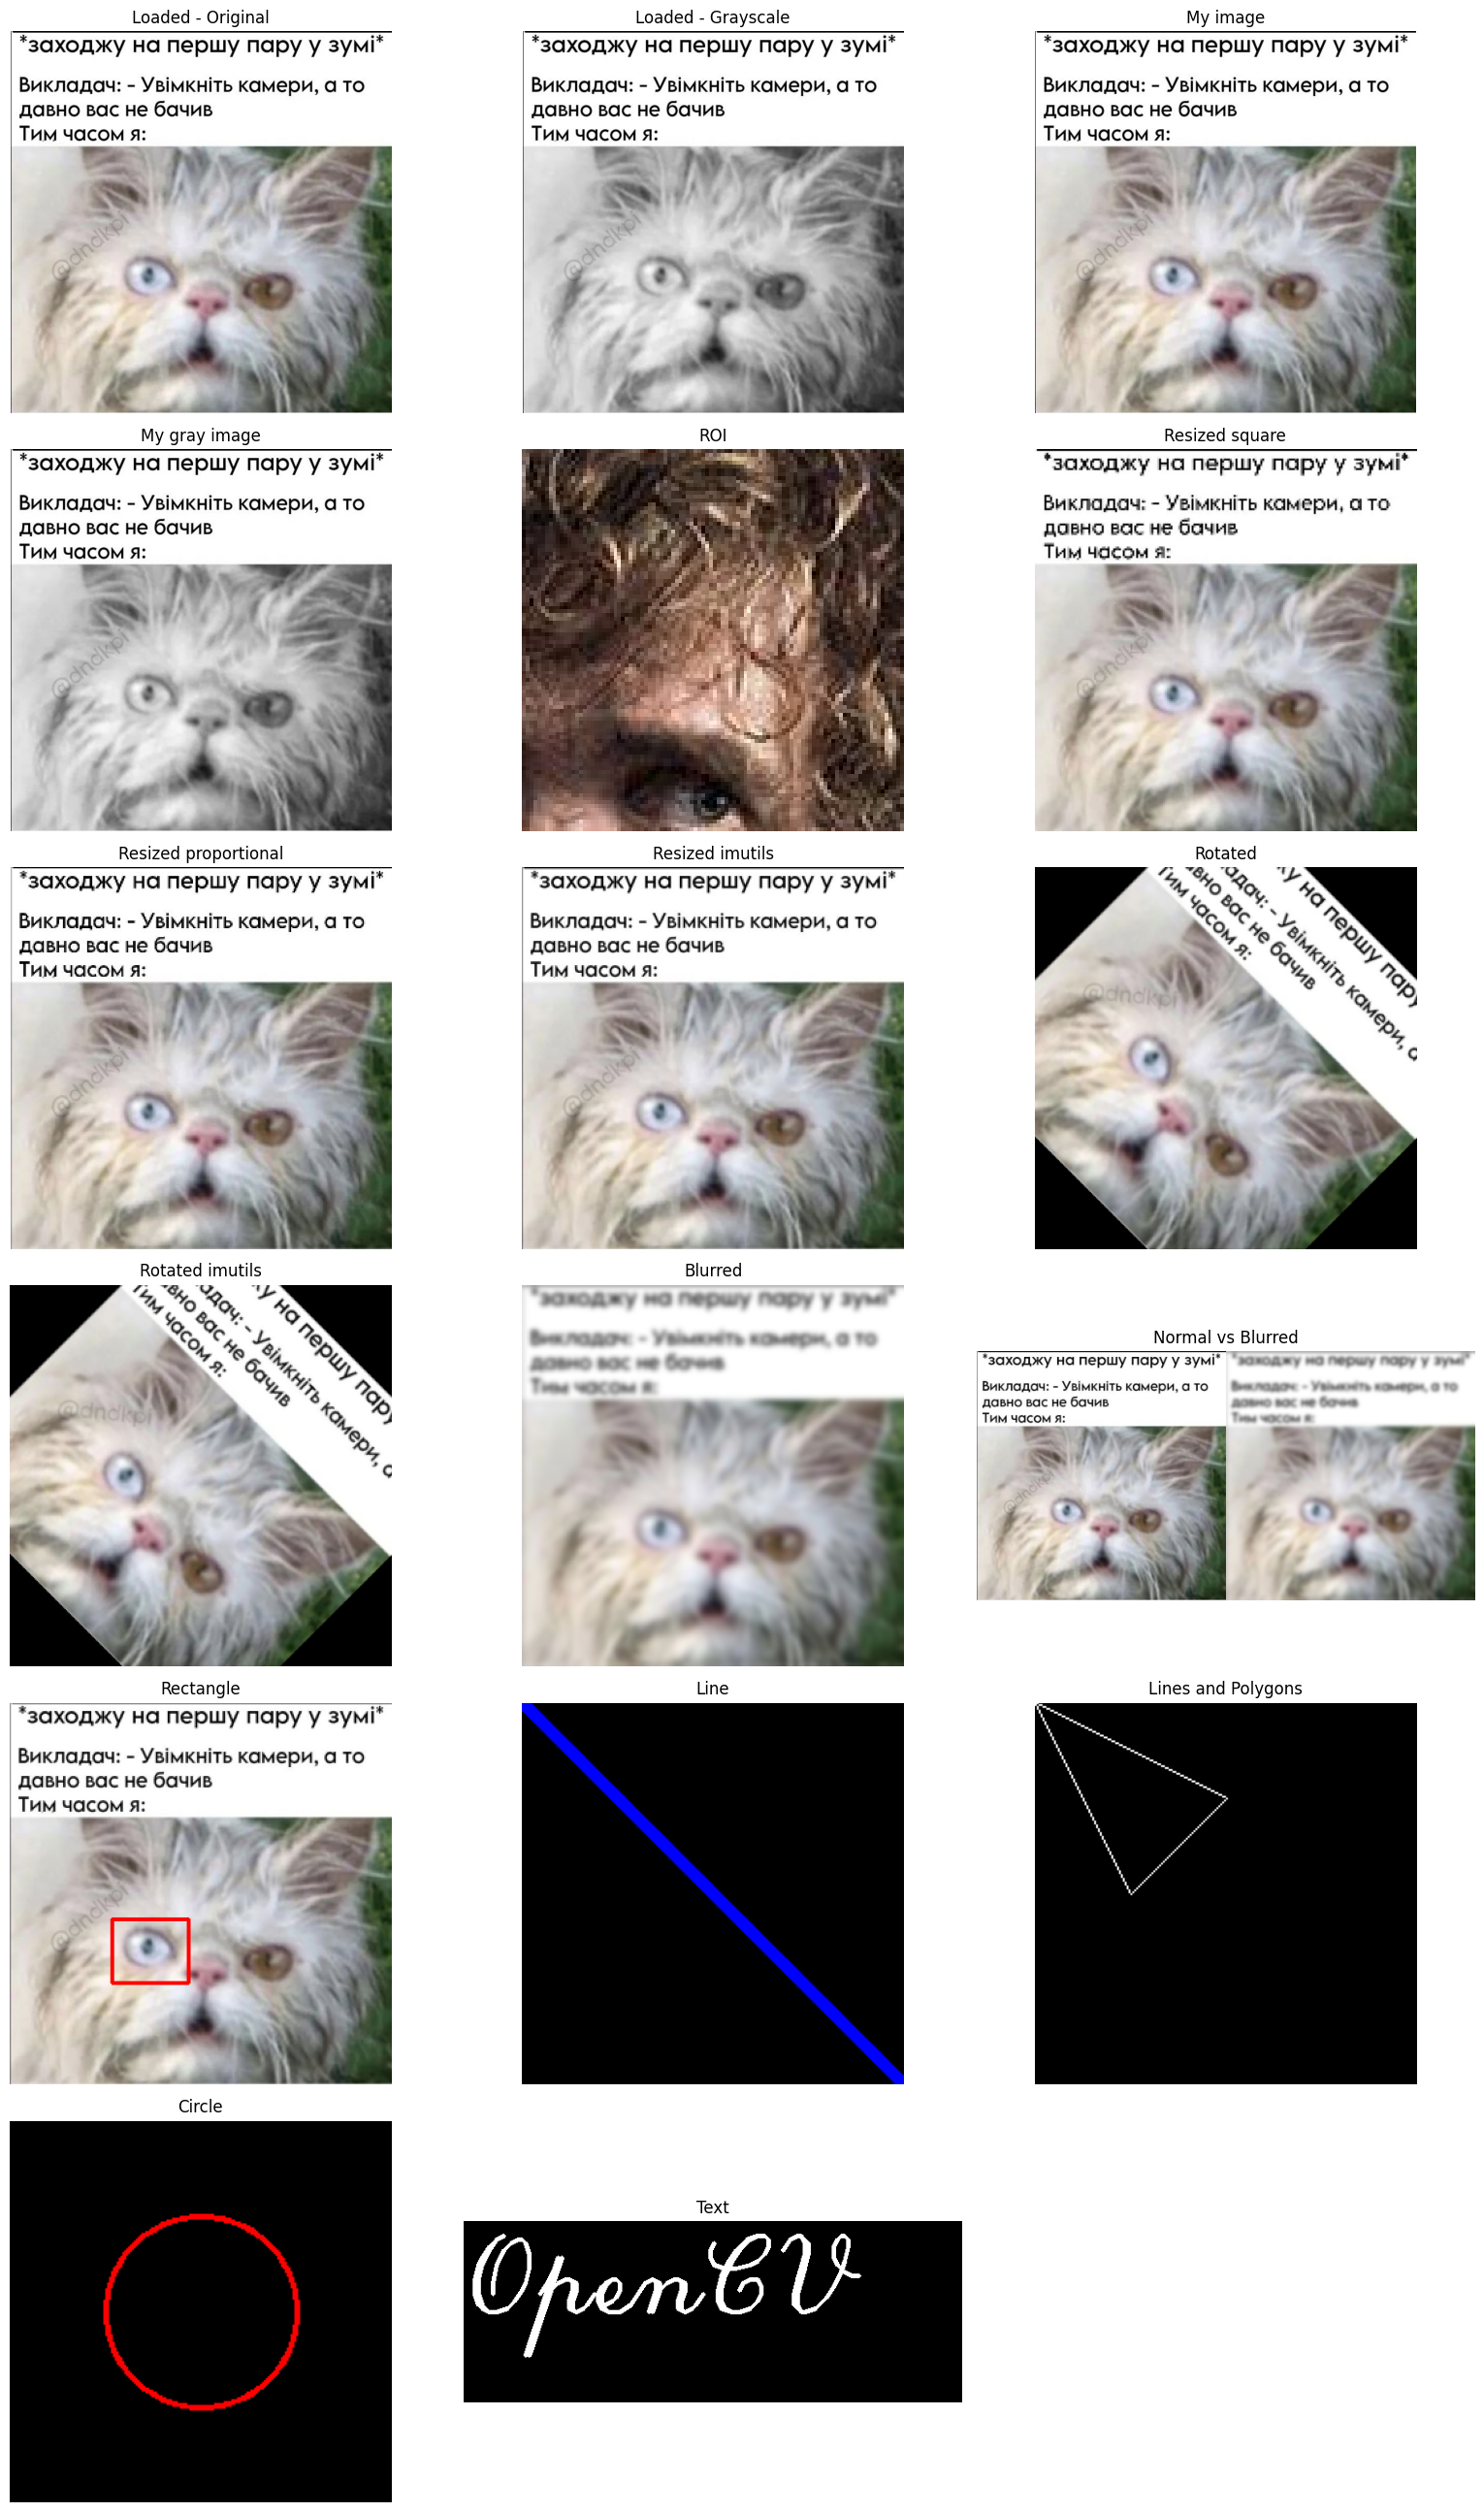


--- Відображення кожного зображення окремо ---



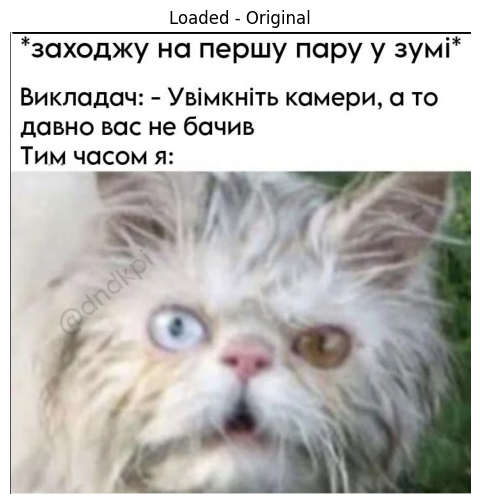

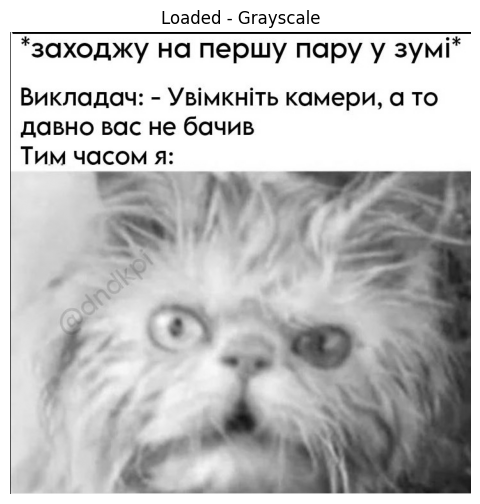

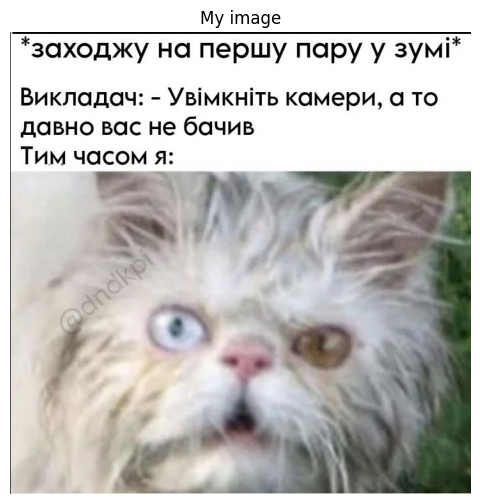

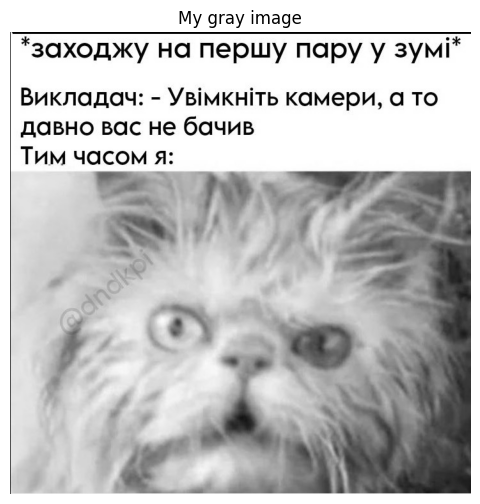

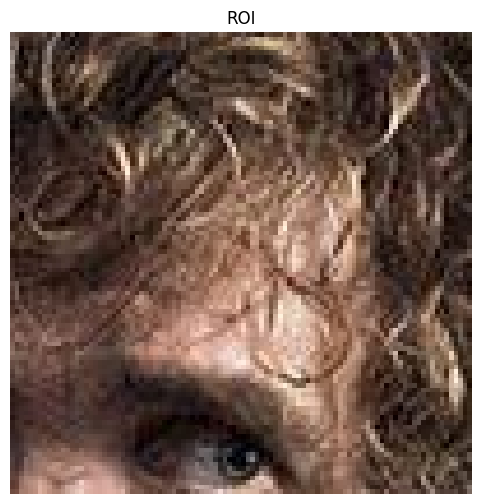

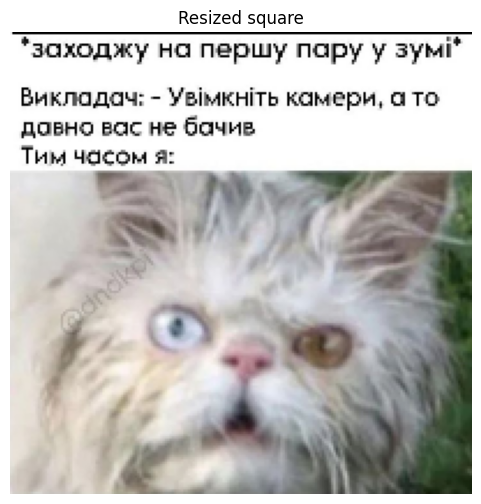

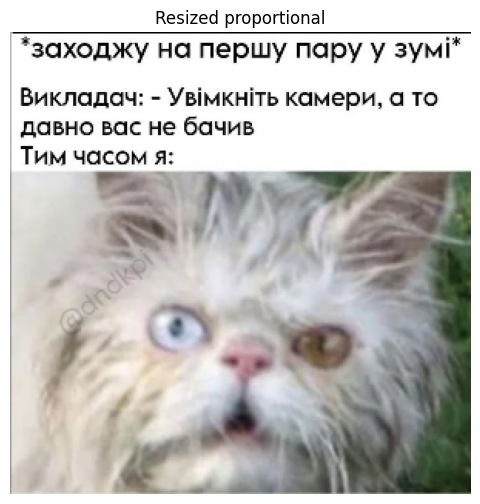

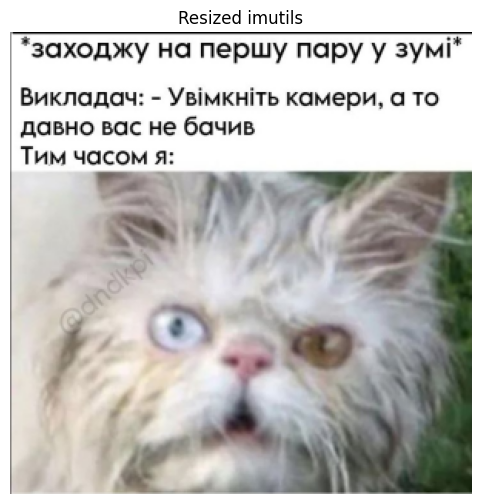

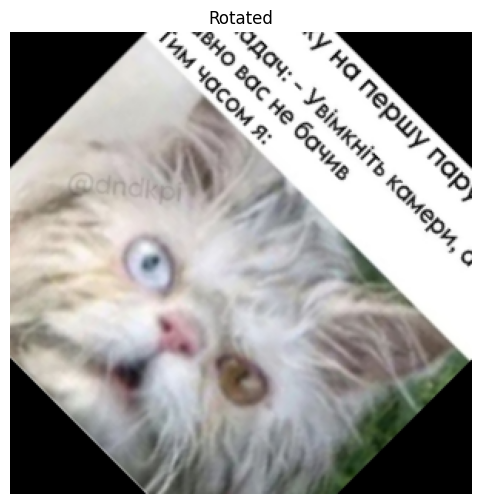

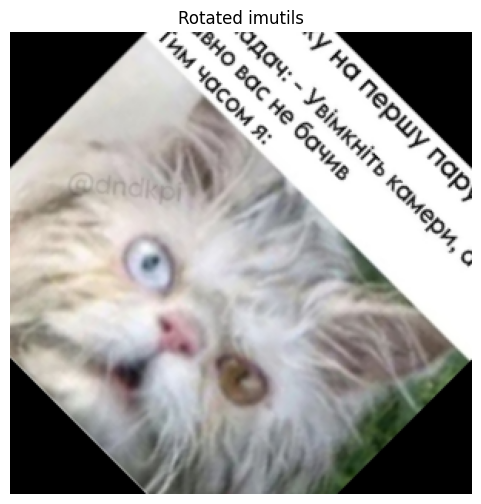

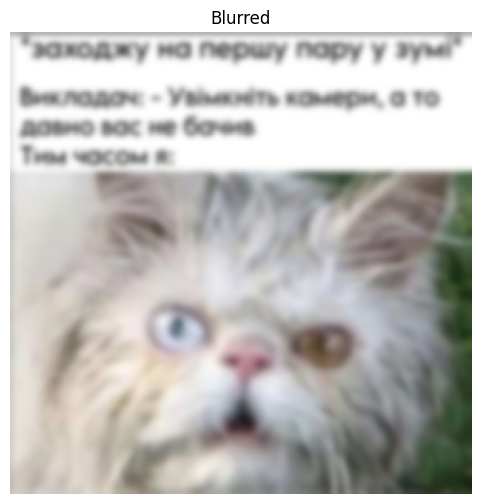

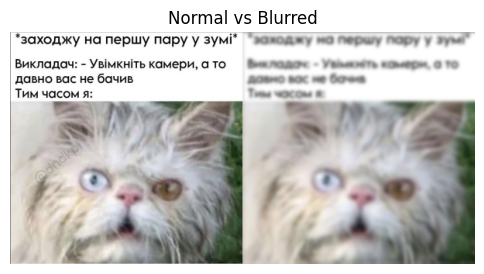

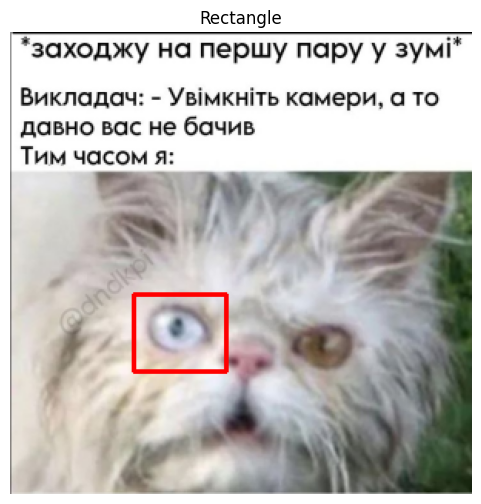

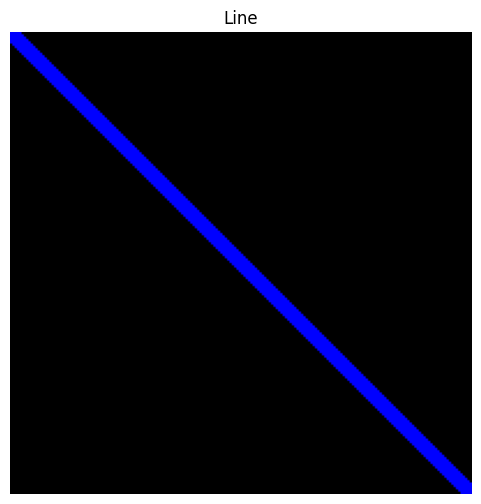

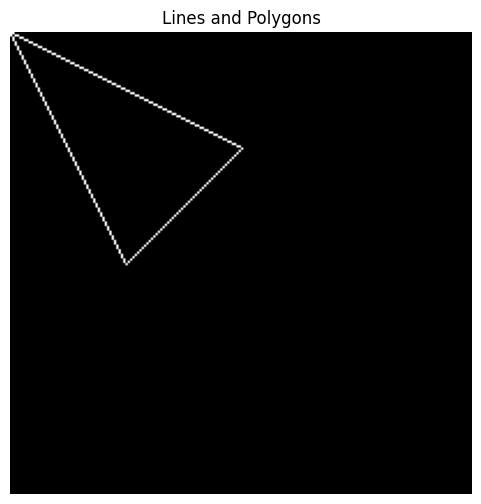

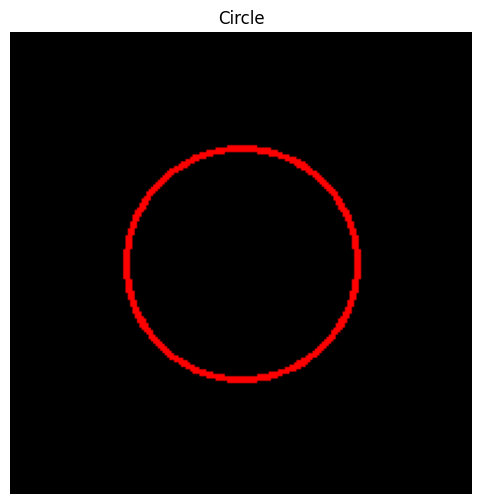

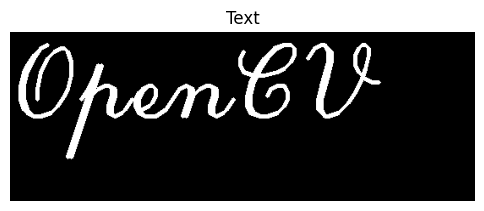

--- Відповіді на Контрольні запитання (Лабораторна робота №1) ---

1) Що таке OpenCV?

OpenCV (Open Source Computer Vision Library) — це бібліотека функцій та алгоритмів комп'ютерного зору, обробки зображень і чисельних алгоритмів загального призначення з відкритим кодом. Вона надає засоби для розпізнавання об'єктів (наприклад, осіб, фігур, тексту), відстежування руху, перетворення зображень та застосування методів машинного навчання.

2) Що таке піксель?

Піксель - це найменший елемент зображення. Всі зображення утворюють прямокутну матрицю з пікселів. Кожен піксель зображення у форматі градації сірого має значення від 0 до 255, що відображає його інтенсивність. У кольоровому просторі (наприклад, BGR у OpenCV) кожен піксель має додаткову інформацію, представлену 3-кортежем значень (синій, зелений, червоний), кожне з яких також знаходиться в діапазоні [0, 255].

3) Як встановити пакет opencv-python?

Встановити цей пакет можна за допомогою менеджера пакетів pip, виконавши у терміналі к

In [2]:
import os
import cv2
import imutils
import numpy as np
import urllib.request
import matplotlib.pyplot as plt

# 1. --- Перевірка версії OpenCV ---
print("OpenCV Version:", cv2.__version__)

# --- Завантаження зображень з GitHub у робочу директорію Kaggle ---
cat_url = "https://raw.githubusercontent.com/YuHryshchenko/zpi-zp41_ai_image_processing_HryshchenkoYuliia_KPI_2026/refs/heads/main/lab01/cat.jpg"
got_url = "https://raw.githubusercontent.com/YuHryshchenko/zpi-zp41_ai_image_processing_HryshchenkoYuliia_KPI_2026/refs/heads/main/lab01/game_of_thrones.jpg"

image_path = 'cat.jpg'
image2_path = 'game_of_thrones.jpg'

print("Завантаження зображень...")
urllib.request.urlretrieve(cat_url, image_path)
urllib.request.urlretrieve(got_url, image2_path)
print("Зображення успішно завантажені!\n")

# --- Налаштування Matplotlib для виводу всіх зображень одночасно ---
fig, axes = plt.subplots(6, 3, figsize=(16, 26))
axes = axes.flatten()
plot_idx = 0

# Список для збереження зображень для їх подальшого індивідуального виводу
all_images = []

def show_img(title, img):
    """Допоміжна функція для виводу зображення через matplotlib та збереження його для окремого виводу"""
    global plot_idx
    
    # Зберігаємо копію для окремого виводу
    all_images.append((title, img.copy()))
    
    if plot_idx < len(axes):
        axes[plot_idx].set_title(title)
        # Якщо зображення у градаціях сірого (має лише 2 виміри)
        if len(img.shape) == 2:
            axes[plot_idx].imshow(img, cmap='gray')
        else:
            # Конвертація кольорів з простору BGR (OpenCV) у RGB (Matplotlib)
            axes[plot_idx].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[plot_idx].axis('off')
        plot_idx += 1

# --- 2. Читання файлу (кольорове та у градаціях сірого) ---
img = cv2.imread(image_path)
if img is None:
    print(f"Помилка: Не вдалося завантажити зображення '{image_path}'.")
else:
    show_img("Loaded - Original", img)

img_gray = cv2.imread(image_path, 0)
show_img("Loaded - Grayscale", img_gray)

# 3. --- Відображення зображення у вікні ---
img = cv2.imread(image_path)
show_img("My image", img)

# 4. --- Збереження файлу ---
saved_image_path = 'saved_foto.jpg'
cv2.imwrite(saved_image_path, img_gray)
img_saved = cv2.imread(saved_image_path)
show_img("My gray image", img_saved)

# 5. --- Доступ до окремих пікселів (x=50, y=100) ---
img = cv2.imread(image_path)
if img.shape[0] > 100 and img.shape[1] > 50:
    (blue, green, red) = img[100, 50]
    print(f"Піксель на (50, 100) -> Червоний (R): {red}, Зелений (G): {green}, Синій (B): {blue}\n")

# --- 6. Вирізання (Crop) регіону інтересу (ROI) ---
img2 = cv2.imread(image2_path)
if img2 is not None and img2.shape[0] > 160 and img2.shape[1] > 420:
    roi = img2[60:160, 320:420]
    show_img("ROI", roi)

# 7. Зміна розміру зображення (непропорційна)
img = cv2.imread(image_path)
resized_square = cv2.resize(img, (200, 200))
show_img("Resized square", resized_square)

# --- 8. Зміна розміру зображення (пропорційна, математичний підхід) ---
img = cv2.imread(image_path)
h, w = img.shape[0:2]
h_new = 300
ratio = w / h
w_new = int(h_new * ratio)
resized_prop = cv2.resize(img, (w_new, h_new))
show_img("Resized proportional", resized_prop)

# --- 9. Зміна розміру за допомогою пакета imutils (зберігає пропорції автоматично) ---
img = cv2.imread(image_path)
resized_imutils = imutils.resize(img, width=300)
show_img("Resized imutils", resized_imutils)

# 10. Поворот зображення за допомогою матриці поворотів (OpenCV)
h_rot, w_rot = resized_imutils.shape[0:2]
center = (w_rot // 2, h_rot // 2)
M = cv2.getRotationMatrix2D(center, -45, 1.0)
rotated_cv2 = cv2.warpAffine(resized_imutils, M, (w_rot, h_rot))
show_img("Rotated", rotated_cv2)

# --- 11. Поворот зображення за допомогою imutils ---
rotated_imutils = imutils.rotate(resized_imutils, -45)
show_img("Rotated imutils", rotated_imutils)

# --- 12. Розмиття зображення (Gaussian Blur) ---
blurred = cv2.GaussianBlur(resized_imutils, (11, 11), 0)
show_img("Blurred", blurred)

# --- 13. Склеювання нормального та розмитого зображень ---
suming = np.hstack((resized_imutils, blurred))
show_img("Normal vs Blurred", suming)

# --- 14. Малювання прямокутника на зображенні ---
img_rect = resized_imutils.copy()
cv2.rectangle(img_rect, (80, 170), (140, 220), (0, 0, 255), 2)
show_img("Rectangle", img_rect)

# --- 15. Створення чорного зображення та малювання лінії ---
img_black = np.zeros((200, 200, 3), np.uint8)
cv2.line(img_black, (0, 0), (200, 200), (255, 0, 0), 5)
show_img("Line", img_black)

# --- 16. Малювання полігону (ліній за набором точок) ---
img_black2 = np.zeros((200, 200, 3), np.uint8)
points = np.array([[0, 0], [100, 50], [50, 100], [0, 0]])
cv2.polylines(img_black2, np.int32([points]), True, (255, 255, 255))
show_img("Lines and Polygons", img_black2)

# --- 17. Малювання кола ---
img_black3 = np.zeros((200, 200, 3), np.uint8)
cv2.circle(img_black3, (100, 100), 50, (0, 0, 255), 2)
show_img("Circle", img_black3)

# --- 18. Розміщення тексту на зображенні ---
img_black4 = np.zeros((200, 550, 3), np.uint8)
font = cv2.FONT_HERSHEY_SCRIPT_COMPLEX
cv2.putText(img_black4, 'OpenCV', (0, 100), font, 4, (255, 255, 255), 4, cv2.LINE_4)
show_img("Text", img_black4)

# --- Приховати порожні рамки для графіків, якщо вони залишилися ---
for i in range(plot_idx, len(axes)):
    axes[i].axis('off')

print("--- Відображення загальної сітки зображень ---")
plt.tight_layout()
plt.show()

# --- ВІДОБРАЖЕННЯ КОЖНОГО ЗОБРАЖЕННЯ ОКРЕМО ---
print("\n--- Відображення кожного зображення окремо ---\n")
for title, img in all_images:
    plt.figure(figsize=(6, 6))
    plt.title(title)
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

# --- Відповіді на Контрольні запитання (Лабораторна робота №1) ---
print("--- Відповіді на Контрольні запитання (Лабораторна робота №1) ---\n")

print("1) Що таке OpenCV?\n")
print("OpenCV (Open Source Computer Vision Library) — це бібліотека функцій та алгоритмів комп'ютерного зору, обробки зображень " \
"і чисельних алгоритмів загального призначення з відкритим кодом. Вона надає засоби для розпізнавання об'єктів "
"(наприклад, осіб, фігур, тексту), відстежування руху, перетворення зображень та застосування методів машинного навчання.\n")

print("2) Що таке піксель?\n")
print("Піксель - це найменший елемент зображення. Всі зображення утворюють прямокутну матрицю з пікселів. Кожен піксель зображення " \
"у форматі градації сірого має значення від 0 до 255, що відображає його інтенсивність. У кольоровому просторі "
"(наприклад, BGR у OpenCV) кожен піксель має додаткову інформацію, представлену 3-кортежем значень (синій, зелений, червоний), " \
"кожне з яких також знаходиться в діапазоні [0, 255].\n")

print("3) Як встановити пакет opencv-python?\n")
print("Встановити цей пакет можна за допомогою менеджера пакетів pip, виконавши у терміналі команду: pip3 install opencv-python.\n")

print("4) Як розмити зображення?\n")
print("Для розмивання зображення та зменшення високочастотного шуму використовується функція Гаусового розмивання cv2.GaussianBlur(). " \
"Наприклад: cv2.GaussianBlur(image, (11, 11), 0).\n")

print("5) Які функції використовуються для малювання та відображення тексту?\n")
print("Для малювання ліній: cv2.line().\n" \
"Для малювання полігонів за точками: cv2.polylines().\n" \
"Для малювання прямокутників: cv2.rectangle().\n" \
"Для малювання кіл: cv2.circle().\n" \
"Для відображення тексту на зображенні: cv2.putText().")
